# Trade-Flow Benchmark — Full Comparison Walkthrough

**Reading key, assumed throughout this notebook** (worth checking this matches your intent before trusting the numbers below):
- **"no-GDELT GAT" / "GAT" / "EdgeGAT"** = GAT without GDELT / GAT with GDELT (all fusion+scoring variants) / EdgeGAT_full (all fusion+combo variants) -- `results_v2_chips_reproduced.csv` has no RF/TabTF/GCN rows at all, so this is the only reading that matches the data.
- **"chips"** = `results_v2_chips_reproduced.csv` -- a plain (no per-product head) model trained *only* on `chips.parquet`.
- **"all products (the first approach)"** = `results_perproduct_head.csv` -- your *first* per-product-head experiment (shared backbone + per-heading weights, **no hierarchical shrinkage yet**), trained on the full `all_products_ready.parquet`. It only covers **4** configs (not the full 19), so sections 2/3 below show chips in full detail with this overlaid only where a matching config exists.
- **"multitask idea vs. classically putting all products at once"** = the already-computed `perproduct_vs_pooled.csv` (per-product head vs. a fully pooled model with no per-product mechanism at all).
- **"per-product head with shrinkage, HS 8541+8542, vs. old approach of chips"** = `results_shrinkage_head.csv`'s `HS_8541_8542_combined` slice vs. `results_v2_chips_reproduced.csv` -- the hierarchical-shrinkage version, evaluated on exactly your chips codes, against the dedicated chips-only model.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#111111', 'axes.facecolor': '#111111', 'savefig.facecolor': '#111111',
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10,
})
BLUE, ORANGE, POS, NEG, GREEN = '#4c8fbd', '#c47f3e', '#2ca02c', '#d62728', '#2ca02c'

def load_v2(path):
    r = pd.read_csv(path)
    r = r.drop_duplicates(['model','fusion','scoring','gdelt','risk_level','agg_mode','missing','tranche'], keep='last')
    return r[r.tranche == 'all']

chips           = load_v2('results_v2_chips_reproduced.csv')
medical         = load_v2('results_v2_medical.csv')
vehicles        = load_v2('results_v2_vehicles.csv')
oil             = load_v2('results_v2_oil.csv')
electronics     = load_v2('results_v2_electro_v2.csv')
first_approach  = pd.read_csv('results_perproduct_head.csv')
fa_overall      = first_approach[first_approach.scope == 'overall'].copy()
fa_overall['is_gat'] = fa_overall.model.str.startswith('GAT')
shrink          = pd.read_csv('results_shrinkage_head.csv')
mvp             = pd.read_csv('perproduct_vs_pooled.csv')
fi_chips        = pd.read_csv('feature_importance_chips.csv')

print('all files loaded OK')

all files loaded OK


## 1. Overall: no-GDELT GAT vs. GAT+GDELT vs. EdgeGAT_full

Best achievable log-R² in each of the three buckets, for **chips** (dedicated model) and **all products (first approach)**.

,chips (dedicated),all products (first approach)
no-GDELT GAT,0.3140,0.324593
GAT+GDELT (best),0.3546,0.319752
EdgeGAT_full (best),0.3083,0.341239


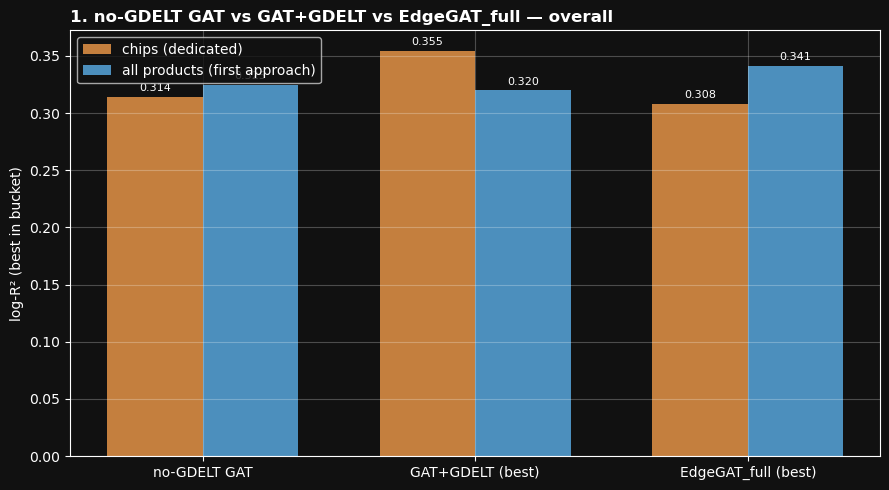

In [2]:
def bucket_scores_chips(df):
    no_gdelt = df[(df.model=='GAT') & (df.scoring=='none')]['log_r2']
    gat_gdelt = df[(df.model=='GAT') & (df.scoring!='none')]['log_r2']
    edge = df[df.model=='EdgeGAT_full']['log_r2']
    return {'no-GDELT GAT': no_gdelt.max(), 'GAT+GDELT (best)': gat_gdelt.max(), 'EdgeGAT_full (best)': edge.max()}

def bucket_scores_first_approach(fa):
    no_gdelt = fa[fa.model=='GAT_first_none_perproduct']['log_r2']
    gat_gdelt = fa[(fa.is_gat) & (fa.model!='GAT_first_none_perproduct')]['log_r2']
    edge = fa[~fa.is_gat]['log_r2']
    return {'no-GDELT GAT': no_gdelt.max(), 'GAT+GDELT (best)': gat_gdelt.max(), 'EdgeGAT_full (best)': edge.max()}

buckets = pd.DataFrame({
    'chips (dedicated)': bucket_scores_chips(chips),
    'all products (first approach)': bucket_scores_first_approach(fa_overall),
})

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(buckets)); w = 0.35
ax.bar(x - w/2, buckets['chips (dedicated)'], w, label='chips (dedicated)', color=ORANGE)
ax.bar(x + w/2, buckets['all products (first approach)'], w, label='all products (first approach)', color=BLUE)
ax.set_xticks(x); ax.set_xticklabels(buckets.index)
ax.set_ylabel('log-R² (best in bucket)')
ax.set_title('1. no-GDELT GAT vs GAT+GDELT vs EdgeGAT_full — overall', loc='left', fontweight='bold')
ax.legend()
for i, col in enumerate(buckets.columns):
    for j, v in enumerate(buckets[col]):
        ax.text(j + (w/2 if i else -w/2), v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
fig.tight_layout()

buckets

## 2. GAT versions — detailed comparison

All 6 GDELT-enabled GAT variants for chips (keepall/topk × concat/blend/attention), plus the no-GDELT baseline. The all-products first-approach experiment only ever trained 2 GAT configs (no-GDELT and topk/concat), so it's overlaid as reference points, not a full second bar group.

,label,fusion,scoring,log_r2,spearman
20,topk/blend,blend,topk,0.3546,0.6141
24,topk/attention,attention,topk,0.3500,0.6214
4,keepall/concat,concat,keepall,0.3330,0.5974
8,keepall/blend,blend,keepall,0.3161,0.5880
0,none,none,none,0.3140,0.5925
16,topk/concat,concat,topk,0.3118,0.6102
12,keepall/attention,attention,keepall,0.2599,0.5828


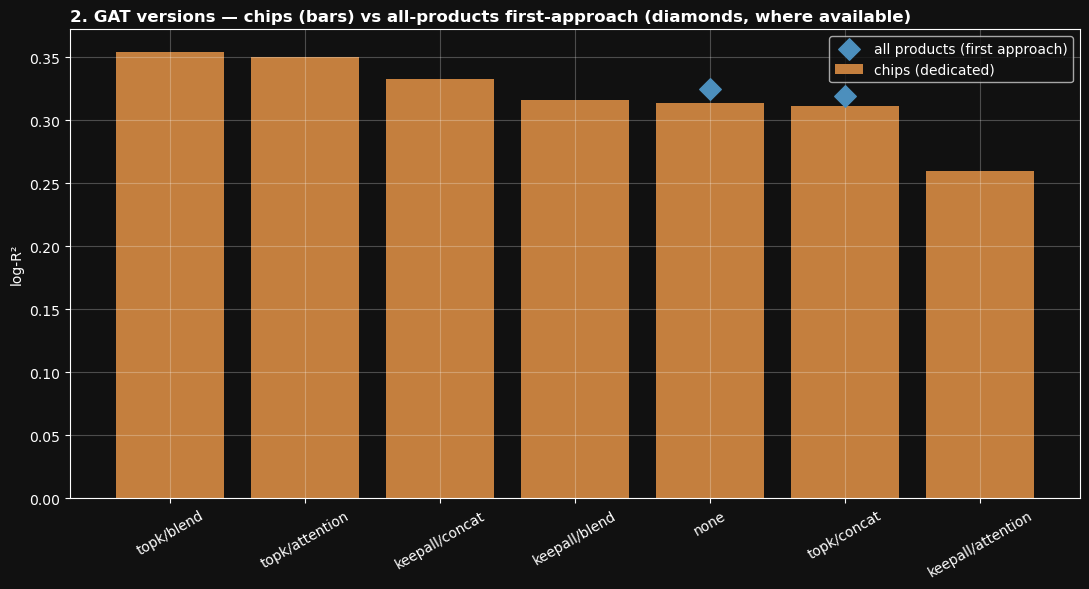

In [3]:
gat_chips = chips[chips.model=='GAT'].copy()
gat_chips['label'] = gat_chips.apply(lambda r: 'none' if r.scoring=='none' else f'{r.scoring}/{r.fusion}', axis=1)
gat_chips = gat_chips.sort_values('log_r2', ascending=False)

fa_gat = fa_overall[fa_overall.is_gat].copy()
fa_gat_map = {'GAT_first_none_perproduct': 'none', 'GAT_first_topk_perproduct': 'topk/concat'}
fa_gat['label'] = fa_gat['model'].map(fa_gat_map)

fig, ax = plt.subplots(figsize=(11,6))
colors = [POS if v>=0 else NEG for v in gat_chips['log_r2']]
ax.bar(gat_chips['label'], gat_chips['log_r2'], color=ORANGE, label='chips (dedicated)')
for _, row in fa_gat.iterrows():
    if row['label'] in gat_chips['label'].values:
        xi = list(gat_chips['label']).index(row['label'])
        ax.scatter(xi, row['log_r2'], color=BLUE, s=120, zorder=5, marker='D',
                   label='all products (first approach)' if xi==list(gat_chips['label']).index(row['label']) else None)
ax.set_ylabel('log-R²'); ax.set_title('2. GAT versions — chips (bars) vs all-products first-approach (diamonds, where available)', loc='left', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
fig.tight_layout()

gat_chips[['label','fusion','scoring','log_r2','spearman']]

## 3. EdgeGAT_full versions — detailed comparison

All 12 EdgeGAT_full variants for chips (4 scorer combos × 3 fusions). All-products first-approach only trained 2 of these (attention/ka_ka, blend/tk_tk), overlaid as reference points.

,label,fusion,scoring,log_r2,spearman
32,ka_ka/blend,blend,ka_ka,0.3083,0.6060
44,tk_tk/blend,blend,tk_tk,0.2941,0.5681
36,ka_ka/attention,attention,ka_ka,0.2719,0.5510
48,tk_tk/attention,attention,tk_tk,0.2698,0.5788
60,ka_tk/attention,attention,ka_tk,0.2496,0.5322
72,tk_ka/attention,attention,tk_ka,0.2421,0.5490
52,ka_tk/concat,concat,ka_tk,0.2369,0.5261
28,ka_ka/concat,concat,ka_ka,0.2328,0.5195
40,tk_tk/concat,concat,tk_tk,0.2284,0.5283
64,tk_ka/concat,concat,tk_ka,0.2217,0.5350


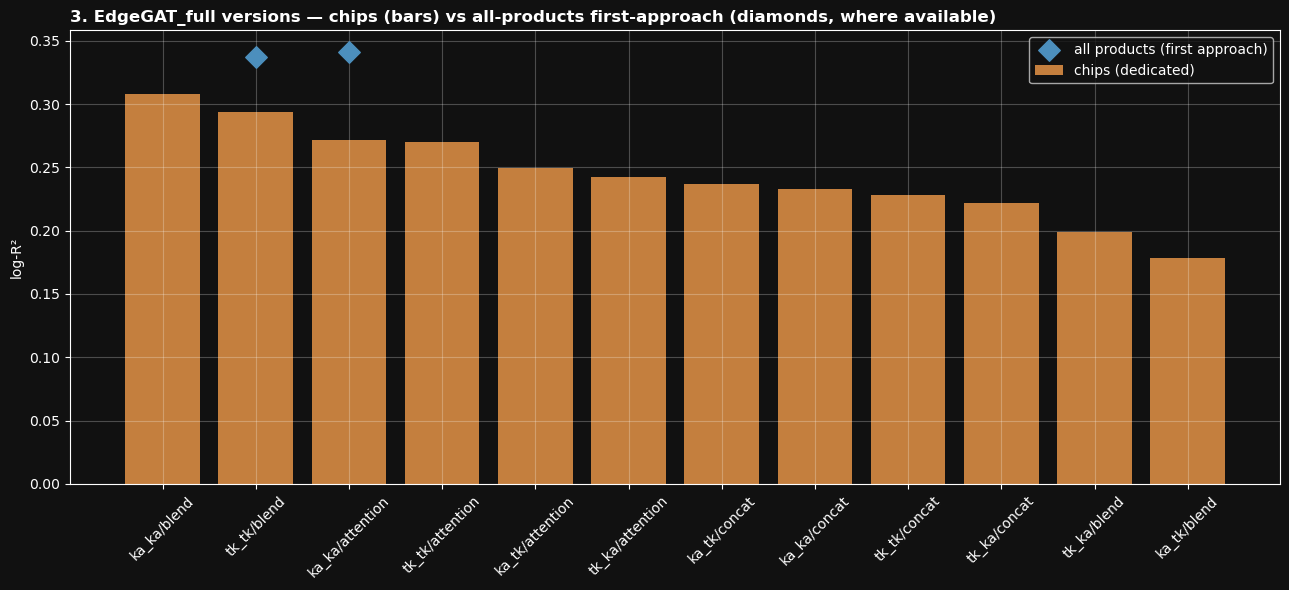

In [4]:
edge_chips = chips[chips.model=='EdgeGAT_full'].copy()
edge_chips['label'] = edge_chips['scoring'] + '/' + edge_chips['fusion']
edge_chips = edge_chips.sort_values('log_r2', ascending=False)

fa_edge = fa_overall[~fa_overall.is_gat].copy()
fa_edge_map = {'EdgeGAT_full_attention_ka_ka_perproduct': 'ka_ka/attention',
               'EdgeGAT_full_blend_tk_tk_perproduct': 'tk_tk/blend'}
fa_edge['label'] = fa_edge['model'].map(fa_edge_map)

fig, ax = plt.subplots(figsize=(13,6))
ax.bar(edge_chips['label'], edge_chips['log_r2'], color=ORANGE, label='chips (dedicated)')
plotted = set()
for _, row in fa_edge.iterrows():
    if row['label'] in edge_chips['label'].values:
        xi = list(edge_chips['label']).index(row['label'])
        lbl = 'all products (first approach)' if 'fa' not in plotted else None
        ax.scatter(xi, row['log_r2'], color=BLUE, s=120, zorder=5, marker='D', label=lbl)
        plotted.add('fa')
ax.set_ylabel('log-R²'); ax.set_title('3. EdgeGAT_full versions — chips (bars) vs all-products first-approach (diamonds, where available)', loc='left', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()

edge_chips[['label','fusion','scoring','log_r2','spearman']]

## 4. Feature importance — chips only

Permutation importance averaged across every model that tested each feature (from `feature_importance_chips.csv`). `refYear` excluded — constant in the 2023-only eval set, so this test can't measure it.

,mean,std,count
feature_clean,,,
gdpcap_o,0.1687,0.0822,6
score_mean,0.1443,0.1791,5
tone_mean,0.1408,0.1079,5
pop_o,0.1034,0.0502,6
active_months,0.0767,0.0614,5
events_total,0.0685,0.0778,5
goldstein_wmean,0.0657,0.0449,5
dist,0.0448,0.0516,6
score_vol,0.0364,0.0620,5


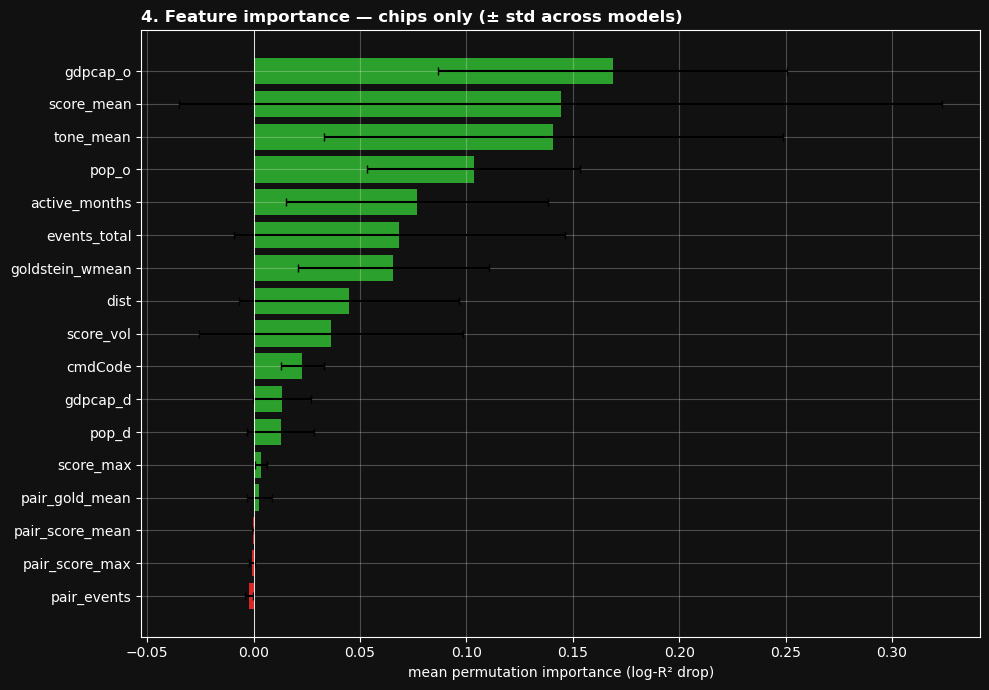

In [5]:
fi = fi_chips.copy()
fi['feature_clean'] = fi['feature'].apply(lambda f: f.split(':', 1)[-1] if ':' in f else f)
fi = fi[fi.feature_clean != 'refYear']
agg = fi.groupby('feature_clean')['importance_log_r2'].agg(['mean','std','count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10,7))
colors = [POS if v>=0 else NEG for v in agg['mean']]
ax.barh(agg.index, agg['mean'], xerr=agg['std'], color=colors, capsize=3)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('mean permutation importance (log-R² drop)')
ax.set_title('4. Feature importance — chips only (± std across models)', loc='left', fontweight='bold')
ax.invert_yaxis()
fig.tight_layout()

agg.round(4)

## 5. Products independently vs. all products (pooled)

Best log-R² among the 4 configs shared by every source (`GAT` no-GDELT, `GAT` concat/topk, `EdgeGAT_full` attention/ka_ka, `EdgeGAT_full` blend/tk_tk) — the only 4 configs `all products (first approach)` actually has, so this is the fair common ground across all 6 sources.

,category,best_of_shared4,n_found
1,vehicles,0.367700,4
0,medical,0.357900,4
5,all products (per-product head),0.341239,4
2,oil,0.333100,4
4,chips,0.314000,4
3,electronics,0.308400,4
6,all products (classical pooled),0.169200,4


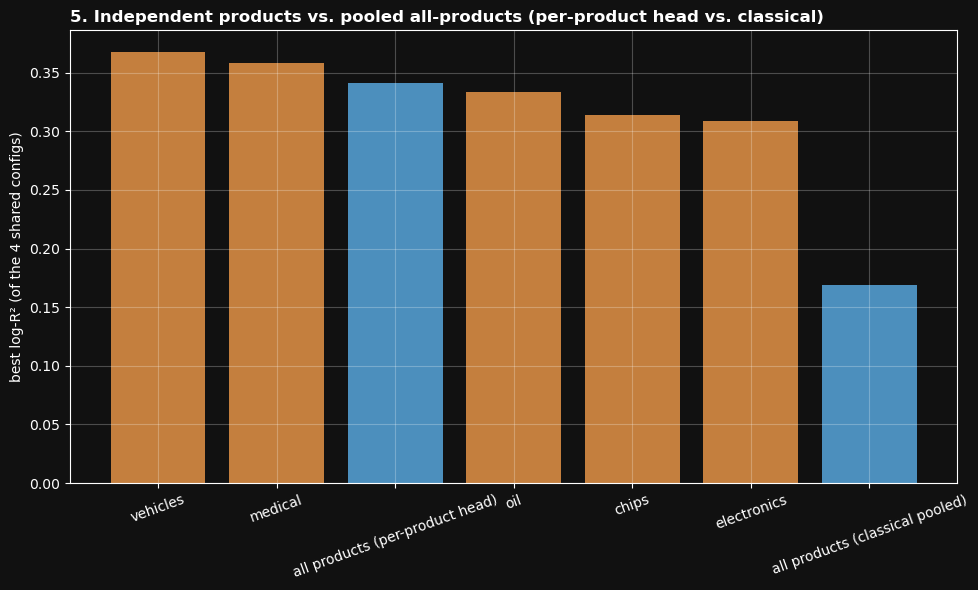

In [10]:
SHARED4 = [('GAT','none','none'), ('GAT','concat','topk'),
           ('EdgeGAT_full','attention','ka_ka'), ('EdgeGAT_full','blend','tk_tk')]
FA_NAMES = {('GAT','none','none'): 'GAT_first_none_perproduct',
            ('GAT','concat','topk'): 'GAT_first_topk_perproduct',
            ('EdgeGAT_full','attention','ka_ka'): 'EdgeGAT_full_attention_ka_ka_perproduct',
            ('EdgeGAT_full','blend','tk_tk'): 'EdgeGAT_full_blend_tk_tk_perproduct'}
# mvp['model'] labels -> the same SHARED4 keys
MVP_NAMES = {('GAT','none','none'): 'GAT no-GDELT',
             ('GAT','concat','topk'): 'GAT concat/topk',
             ('EdgeGAT_full','attention','ka_ka'): 'EdgeGAT_full attn/ka_ka',
             ('EdgeGAT_full','blend','tk_tk'): 'EdgeGAT_full blend/tk_tk'}

categories = {'medical': medical, 'vehicles': vehicles, 'oil': oil, 'electronics': electronics, 'chips': chips}
rows = []
for cat_name, df in categories.items():
    vals = []
    for m, f, s in SHARED4:
        sub = df[(df.model==m) & (df.fusion==f) & (df.scoring==s)]
        if len(sub): vals.append(sub.iloc[0]['log_r2'])
    rows.append({'category': cat_name, 'best_of_shared4': max(vals) if vals else np.nan, 'n_found': len(vals)})

fa_vals = []
for key, name in FA_NAMES.items():
    sub = fa_overall[fa_overall.model == name]
    if len(sub): fa_vals.append(sub.iloc[0]['log_r2'])
rows.append({'category': 'all products (per-product head)', 'best_of_shared4': max(fa_vals), 'n_found': len(fa_vals)})

# NEW: the classical fully-pooled model, no per-product head at all
classical_vals = []
for key, label in MVP_NAMES.items():
    sub = mvp[mvp['model'] == label]
    if len(sub): classical_vals.append(sub.iloc[0]['pooled_log_r2'])
rows.append({'category': 'all products (classical pooled)', 'best_of_shared4': max(classical_vals), 'n_found': len(classical_vals)})

cat_comp = pd.DataFrame(rows).sort_values('best_of_shared4', ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
colors = [BLUE if 'all products' in c else ORANGE for c in cat_comp['category']]
ax.bar(cat_comp['category'], cat_comp['best_of_shared4'], color=colors)
ax.set_ylabel('best log-R² (of the 4 shared configs)')
ax.set_title('5. Independent products vs. pooled all-products (per-product head vs. classical)', loc='left', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()

cat_comp

## 6a. Multitask idea (per-product head) vs. classically pooling all products at once

Directly from `perproduct_vs_pooled.csv` — a fully pooled model (no per-product mechanism at all) vs. the first per-product-head version, same 4 configs, same all-products test set.

,model,pooled_log_r2,perhead_log_r2,delta_log_r2
0,GAT no-GDELT,0.1114,0.324593,0.213193
1,GAT concat/topk,0.0643,0.319752,0.255452
2,EdgeGAT_full attn/ka_ka,-0.0074,0.341239,0.348639
3,EdgeGAT_full blend/tk_tk,0.1692,0.337088,0.167888


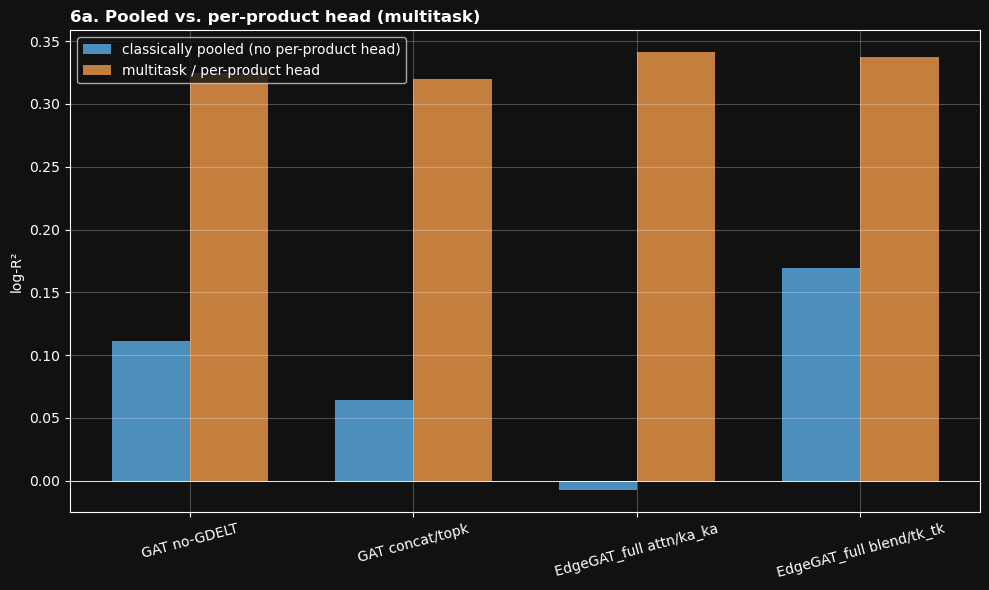

In [7]:
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(mvp)); w = 0.35
ax.bar(x - w/2, mvp['pooled_log_r2'], w, label='classically pooled (no per-product head)', color=BLUE)
ax.bar(x + w/2, mvp['perhead_log_r2'], w, label='multitask / per-product head', color=ORANGE)
ax.set_xticks(x); ax.set_xticklabels(mvp['model'], rotation=15)
ax.axhline(0, color='w', lw=.6)
ax.set_ylabel('log-R²'); ax.set_title('6a. Pooled vs. per-product head (multitask)', loc='left', fontweight='bold')
ax.legend()
fig.tight_layout()

mvp[['model','pooled_log_r2','perhead_log_r2','delta_log_r2']]

## 6b. Per-product head **with shrinkage**, HS 8541+8542 slice, vs. the old dedicated-chips approach

The final evolution: same idea as 6a, but with hierarchical shrinkage added, evaluated on exactly your chips codes (8541+8542) as part of the full pooled model, against the dedicated `chips.parquet`-only model.

**Caveat:** `n` differs between the two sides (≈378 for the pooled slice vs. 1,611 for the dedicated chips run) — different train/test construction, not the same exact rows. Directional evidence, not a bit-for-bit match.

Pooled + shrinkage beats the dedicated chips-only model in 17 / 19 configs.


,chips_dedicated,shrinkage_8541_8542,delta,chips_n,shrinkage_n
label,,,,,
EdgeGAT_full_blend_ka_tk,0.1784,0.497180,0.318780,1611,378
EdgeGAT_full_blend_tk_ka,0.1990,0.489327,0.290327,1611,378
EdgeGAT_full_concat_ka_tk,0.2369,0.498457,0.261557,1611,378
EdgeGAT_full_concat_tk_tk,0.2284,0.478672,0.250272,1611,378
EdgeGAT_full_concat_tk_ka,0.2217,0.469630,0.247930,1611,378
EdgeGAT_full_attention_tk_ka,0.2421,0.455296,0.213196,1611,378
EdgeGAT_full_attention_tk_tk,0.2698,0.478722,0.208922,1611,378
GAT_first_keepall_attention,0.2599,0.466139,0.206239,1611,378
EdgeGAT_full_blend_ka_ka,0.3083,0.478118,0.169818,1611,378


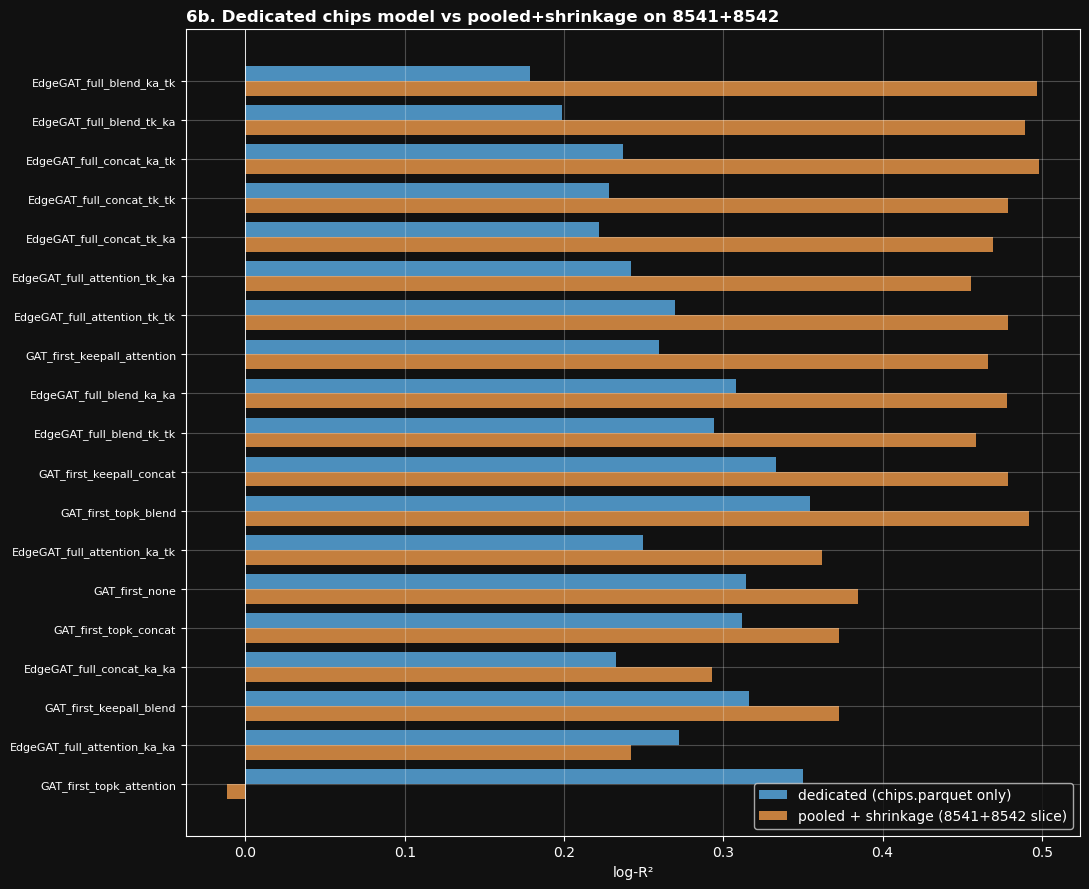

In [13]:
def parse_shrinkage_name(name):
    n = name.replace('_shrinkage', '')
    if n == 'GAT_first_none':
        return ('GAT', 'none', 'none')
    if n.startswith('GAT_first_'):
        rest = n[len('GAT_first_'):]
        scoring, fusion = rest.rsplit('_', 1)
        return ('GAT', fusion, scoring)
    if n.startswith('EdgeGAT_full_'):
        rest = n[len('EdgeGAT_full_'):]
        fusion, combo = rest.split('_', 1)
        return ('EdgeGAT_full', fusion, combo)
    raise ValueError(name)

combo_rows = shrink[shrink.scope == 'HS_8541_8542_combined']
rows = []
for _, row in combo_rows.iterrows():
    m, f, s = parse_shrinkage_name(row['model'])
    match = chips[(chips.model==m) & (chips.fusion==f) & (chips.scoring==s)]
    if len(match) == 0:
        continue
    rows.append({'label': row['model'].replace('_shrinkage',''),
                 'shrinkage_8541_8542': row['log_r2'], 'chips_dedicated': match.iloc[0]['log_r2'],
                 'shrinkage_n': row['n'], 'chips_n': match.iloc[0]['n']})

comp = pd.DataFrame(rows).set_index('label')
comp['delta'] = comp['shrinkage_8541_8542'] - comp['chips_dedicated']
comp = comp.sort_values('delta', ascending=False)
n_beat = (comp['delta'] > 0).sum()
print(f'Pooled + shrinkage beats the dedicated chips-only model in {n_beat} / {len(comp)} configs.')

fig, ax = plt.subplots(figsize=(11,9))
y = np.arange(len(comp)); w = 0.38
ax.barh(y - w/2, comp['chips_dedicated'], w, label='dedicated (chips.parquet only)', color=BLUE)
ax.barh(y + w/2, comp['shrinkage_8541_8542'], w, label='pooled + shrinkage (8541+8542 slice)', color=ORANGE)
ax.set_yticks(y); ax.set_yticklabels(comp.index, fontsize=8)
ax.axvline(0, color='w', lw=.6)
ax.set_xlabel('log-R²'); ax.set_title('6b. Dedicated chips model vs pooled+shrinkage on 8541+8542', loc='left', fontweight='bold')
ax.legend(loc='lower right'); ax.invert_yaxis()
fig.tight_layout()

comp[['chips_dedicated','shrinkage_8541_8542','delta','chips_n','shrinkage_n']]

,old approach (dedicated chips.parquet),"new approach (pooled + shrinkage, 8541+8542)"
no-GDELT GAT,0.3140,0.384663
GAT+GDELT (best),0.3546,0.492228
EdgeGAT_full (best),0.3083,0.498457


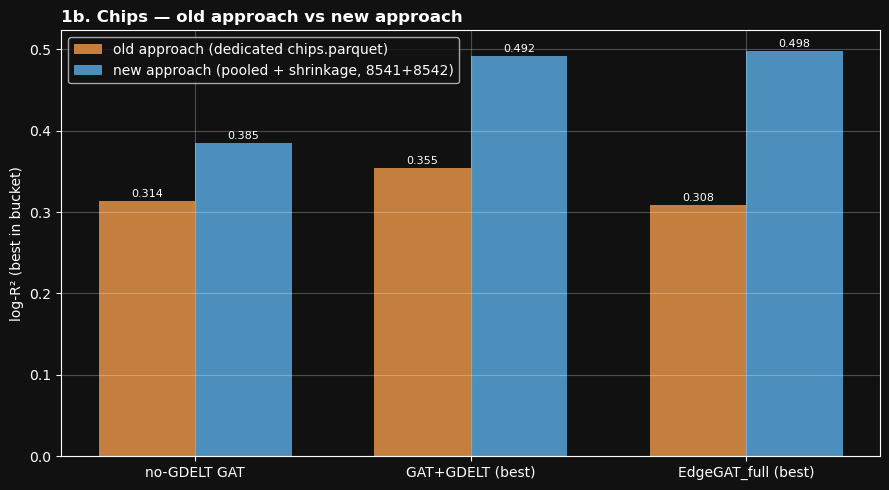

In [14]:
def parse_shrinkage_name(name):
    n = name.replace('_shrinkage', '')
    if n == 'GAT_first_none':
        return ('GAT', 'none', 'none')
    if n.startswith('GAT_first_'):
        rest = n[len('GAT_first_'):]
        scoring, fusion = rest.rsplit('_', 1)
        return ('GAT', fusion, scoring)
    if n.startswith('EdgeGAT_full_'):
        rest = n[len('EdgeGAT_full_'):]
        fusion, combo = rest.split('_', 1)
        return ('EdgeGAT_full', fusion, combo)
    raise ValueError(name)

combo_rows = shrink[shrink.scope == 'HS_8541_8542_combined'].copy()
parsed = combo_rows['model'].apply(parse_shrinkage_name)
combo_rows['pmodel']   = [p[0] for p in parsed]
combo_rows['pscoring'] = [p[2] for p in parsed]

def bucket_scores(df, model_col, scoring_col):
    no_gdelt  = df[(df[model_col]=='GAT') & (df[scoring_col]=='none')]['log_r2']
    gat_gdelt = df[(df[model_col]=='GAT') & (df[scoring_col]!='none')]['log_r2']
    edge      = df[df[model_col]=='EdgeGAT_full']['log_r2']
    return {'no-GDELT GAT': no_gdelt.max(), 'GAT+GDELT (best)': gat_gdelt.max(), 'EdgeGAT_full (best)': edge.max()}

buckets_chips_compare = pd.DataFrame({
    'old approach (dedicated chips.parquet)': bucket_scores(chips, 'model', 'scoring'),
    'new approach (pooled + shrinkage, 8541+8542)': bucket_scores(combo_rows, 'pmodel', 'pscoring'),
})

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(buckets_chips_compare)); w = 0.35
ax.bar(x - w/2, buckets_chips_compare['old approach (dedicated chips.parquet)'], w,
       label='old approach (dedicated chips.parquet)', color=ORANGE)
ax.bar(x + w/2, buckets_chips_compare['new approach (pooled + shrinkage, 8541+8542)'], w,
       label='new approach (pooled + shrinkage, 8541+8542)', color=BLUE)
ax.set_xticks(x); ax.set_xticklabels(buckets_chips_compare.index)
ax.set_ylabel('log-R² (best in bucket)')
ax.set_title('1b. Chips — old approach vs new approach', loc='left', fontweight='bold')
ax.legend()
for i, col in enumerate(buckets_chips_compare.columns):
    for j, v in enumerate(buckets_chips_compare[col]):
        ax.text(j + (w/2 if i else -w/2), v + 0.005, f'{v:.3f}', ha='center', fontsize=8)
fig.tight_layout()

buckets_chips_compare